# Zero-Shot Foundation Models for Sub-THz Blockage Prediction

**Research question.** Can off-the-shelf foundation models — without any task-specific training — predict an imminent sub-THz link blockage from a short window of recent RSSI samples?

**Setup.** Six model families are compared in parallel:

| Slot | Family | Example | Input representation |
|------|--------|---------|----------------------|
| 1 | Generative LLM | `Qwen/Qwen2.5-3B-Instruct` | RSSI history as a compact numeric list in the prompt |
| 2 | Telecom LLM | `AliMaatouk/LLama-3-8B-Tele-it` | RSSI history + telecom-domain instruction prompt |
| 3 | Vision–Language | `HuggingFaceTB/SmolVLM-Instruct` | PNG plot of the RSSI trace |
| 4 | BERT (NLI zero-shot) | `facebook/bart-large-mnli` | Text summary with candidate labels |
| 5 | Time-series FM | `google/timesfm-2.5-200m-pytorch` | Raw numeric history → forecast |
| 6 | Tabular FM (in-context) | TabPFN v2 (PriorLabs, ~2.6) | Hand-crafted statistics of the window |

**Data.** 8 measurement sets (varying TX height & distances) × 30 traces × 80 000 samples @ 20 kHz (4 s each). The trace files have the time column in seconds; consecutive rows differ by 5×10⁻⁵ s = **50 µs per sample** (so 20 samples per millisecond, *not* 2 samples per microsecond).

**Protocol.**
1. Visualise the traces and pick a blockage threshold (§1).
2. Label each sample + each future-horizon window (§2).
3. Build sliding history-windows → horizon labels (§3).
4. Run each of the 6 models zero-shot (or in-context, for TabPFN) and record binary predictions (§4).
5. Compute accuracy / F1 / confusion matrix per (model, history-size) (§5).

The horizon is fixed at **10 ms** (= 200 samples, matching a 6G frame). History size is swept over **{20, 50, 100} ms** to find the best context length.

In [26]:
# First-run only — installs ~25 GB of model weights across the 6 backbones.
# Re-run is a no-op once cached under ~/.cache/huggingface.
%pip install --quiet \
    "transformers>=4.44" torch torchvision sentencepiece accelerate \
    matplotlib seaborn tqdm scikit-learn pyarrow pandas pillow einops \
    tabpfn
# TimesFM 2.5 is only on GitHub; install editable from the local clone.
# The bare `./timesfm/` directory shadows imports as a namespace package
# until the editable install registers `./timesfm/src/timesfm/` properly.
%pip install --quiet -e "./timesfm[torch]"



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
import os, re, io, json, time, gc, math, warnings
from pathlib import Path
from dataclasses import dataclass, asdict, field
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(context="notebook", style="whitegrid")

PROJECT_ROOT = Path("/Users/kaefcatcher/Projects/Research_Seminar/THz_res")
DATA_DIR     = PROJECT_ROOT / "data"
CACHE_DIR    = PROJECT_ROOT / ".cache_npz"
RESULTS_DIR  = PROJECT_ROOT / "results"
CACHE_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

FS              = 20_000                         # Hz: 1 sample per 50 us = 20 samples/ms
HORIZON_MS      = 10
HORIZON_N       = FS * HORIZON_MS // 1000        # 200 samples
HISTORY_GRID_MS = [20, 50, 100]                  # 400 / 1000 / 2000 samples
STRIDE_N        = 1000                           # 50 ms between window starts
FILES_PER_SET   = 3                              # eval scope (24 traces total)
RNG_SEED        = 0
MIN_EVENT_LEN   = 5                              # samples; ~0.25 ms de-noise

if torch.cuda.is_available():
    DEVICE = "cuda"
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"torch={torch.__version__}, device={DEVICE}")
print(f"DATA_DIR={DATA_DIR}, exists={DATA_DIR.exists()}")


torch=2.11.0, device=mps
DATA_DIR=/Users/kaefcatcher/Projects/Research_Seminar/THz_res/data, exists=True


## §1 Data loading utilities

Each measurement file is **tab-delimited**, 80 000 rows × 3 columns:
`time_seconds \t rss_linear \t power_dB`. We use only columns 0 and 1; column 2 is a redundant dB copy.

Parsing 19 M rows every session is wasteful, so the first call per file caches a compact `.npz` under `.cache_npz/`.


In [28]:
_META_RE = re.compile(
    r"Set(?P<set>\d+)_H=(?P<H>\d+)cm_L13=(?P<L13>\d+)cm_L12=(?P<L12>\d+)cm"
)

def parse_folder_meta(name: str) -> dict:
    m = _META_RE.match(name)
    if not m:
        raise ValueError(f"Unexpected folder name: {name}")
    return {k: int(v) for k, v in m.groupdict().items()}


def load_file(path: Path) -> np.ndarray:
    """Return shape (80000, 2): col0=time(s), col1=RSS(linear)."""
    return np.loadtxt(path, delimiter="\t", usecols=(0, 1))


def load_cached(set_name: str, path: Path) -> tuple[np.ndarray, np.ndarray]:
    """First call parses + caches as .npz; subsequent calls np.load."""
    key = CACHE_DIR / f"{set_name}__{path.name}.npz"
    if not key.exists():
        arr = load_file(path)
        np.savez_compressed(key, t=arr[:, 0].astype(np.float32),
                                 rss=arr[:, 1].astype(np.float64))
    with np.load(key) as z:
        return z["t"].copy(), z["rss"].copy()


def iter_sets(data_dir: Path = DATA_DIR) -> list[dict]:
    sets = []
    for sub in sorted(data_dir.iterdir()):
        if not sub.is_dir() or not sub.name.startswith("Set"):
            continue
        meta = parse_folder_meta(sub.name)
        files = sorted(
            (p for p in sub.iterdir() if p.name.startswith("DATA_UNCAL_Meas")),
            key=lambda p: int(re.search(r"Meas(\d+)", p.name).group(1)),
        )
        sets.append({"set_name": sub.name, "meta": meta, "files": files})
    sets.sort(key=lambda s: s["meta"]["set"])
    return sets


def select_eval_files(files_per_set: int = FILES_PER_SET,
                      seed: int = RNG_SEED) -> list[tuple[str, Path]]:
    rng = np.random.default_rng(seed)
    out: list[tuple[str, Path]] = []
    for s in iter_sets():
        idx = rng.choice(len(s["files"]),
                         size=min(files_per_set, len(s["files"])),
                         replace=False)
        for i in sorted(idx):
            out.append((s["set_name"], s["files"][i]))
    return out


SETS = iter_sets()
EVAL_FILES = select_eval_files()
print(f"Discovered {len(SETS)} sets, {sum(len(s['files']) for s in SETS)} traces total.")
print(f"Eval subset: {len(EVAL_FILES)} traces ({FILES_PER_SET}/set).")
for s in SETS:
    print(f"  {s['set_name']}: H={s['meta']['H']}cm L13={s['meta']['L13']}cm "
          f"L12={s['meta']['L12']}cm ({len(s['files'])} files)")


Discovered 8 sets, 240 traces total.
Eval subset: 24 traces (3/set).
  Set1_H=135cm_L13=450cm_L12=150cm: H=135cm L13=450cm L12=150cm (30 files)
  Set2_H=135cm_L13=450cm_L12=225cm: H=135cm L13=450cm L12=225cm (30 files)
  Set3_H=135cm_L13=450cm_L12=300cm: H=135cm L13=450cm L12=300cm (30 files)
  Set4_H=165cm_L13=450cm_L12=150cm: H=165cm L13=450cm L12=150cm (30 files)
  Set5_H=165cm_L13=450cm_L12=225cm: H=165cm L13=450cm L12=225cm (30 files)
  Set6_H=165cm_L13=450cm_L12=300cm: H=165cm L13=450cm L12=300cm (30 files)
  Set7_H=165cm_L13=300cm_L12=150cm: H=165cm L13=300cm L12=150cm (30 files)
  Set8_H=135cm_L13=300cm_L12=150cm: H=135cm L13=300cm L12=150cm (30 files)


In [29]:
# Smoke-test one file end-to-end.
_set, _path = EVAL_FILES[0]
_t, _rss = load_cached(_set, _path)
assert _t.shape == (80_000,) and _rss.shape == (80_000,)
assert abs(_t[0] + 2.0) < 1e-3
assert abs(_t[1] - _t[0] - 1 / FS) < 1e-6
print(f"OK: {_set}/{_path.name}")
print(f"  t:   {_t[0]:.4f} ... {_t[-1]:.4f} s   (dt={_t[1]-_t[0]:.2e}s)")
print(f"  rss: min={_rss.min():.3e}  max={_rss.max():.3e}  median={np.median(_rss):.3e}")


OK: Set1_H=135cm_L13=450cm_L12=150cm/DATA_UNCAL_Meas16
  t:   -2.0000 ... 2.0000 s   (dt=4.99e-05s)
  rss: min=-5.247e-07  max=8.410e-06  median=5.240e-06


## §1 (user section 1) — Visualization & threshold selection

We eyeball all 8 sets side-by-side to choose a blockage threshold. The RSSI distribution across a full trace typically looks bimodal — a high-amplitude "link-available" mode and a low-amplitude "blocked" mode — in which case a simple percentile threshold is defensible.


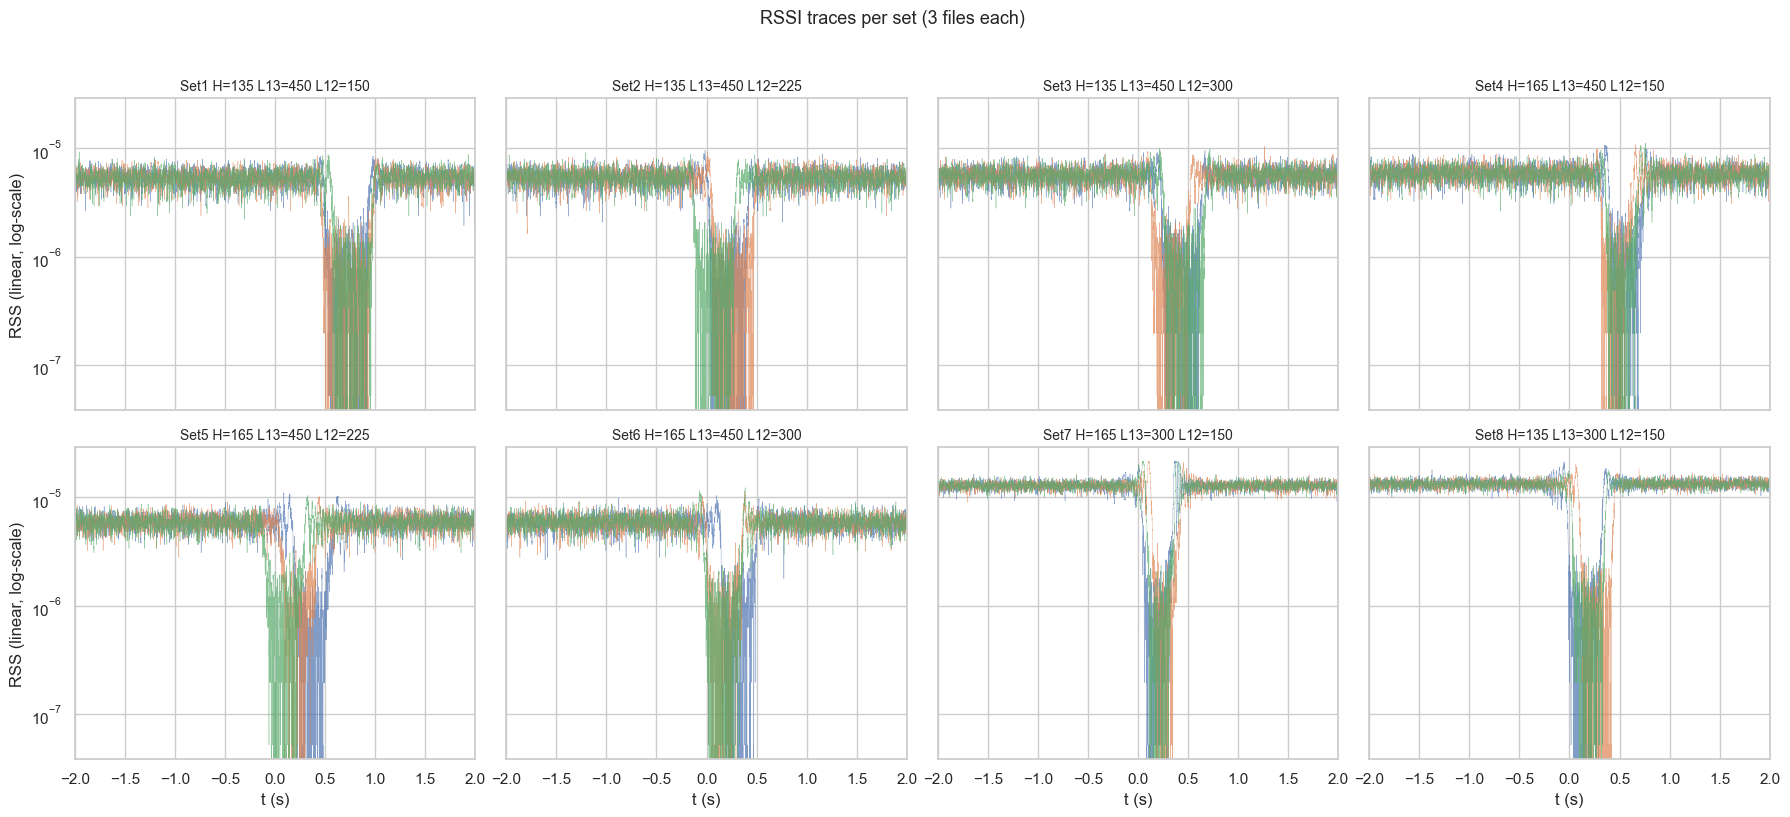

In [30]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
for ax, s in zip(axes.flat, SETS):
    picks = [p for (sn, p) in EVAL_FILES if sn == s["set_name"]]
    for p in picks:
        t, rss = load_cached(s["set_name"], p)
        ax.plot(t, rss, lw=0.3, alpha=0.7)
    ax.set_yscale("log")
    ax.set_title(f"Set{s['meta']['set']} H={s['meta']['H']} "
                 f"L13={s['meta']['L13']} L12={s['meta']['L12']}", fontsize=10)
    ax.set_xlim(-2, 2)
for ax in axes[-1]:
    ax.set_xlabel("t (s)")
for ax in axes[:, 0]:
    ax.set_ylabel("RSS (linear, log-scale)")
fig.suptitle("RSSI traces per set (3 files each)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


RSS percentiles (linear): p5=1.061e-06 p10=3.943e-06  p15=4.519e-06  p25=5.096e-06  p50=5.960e-06


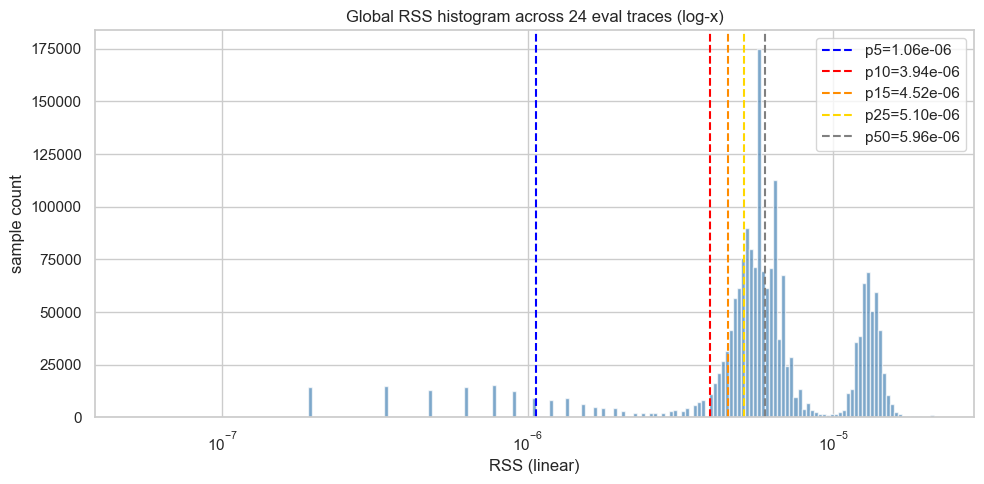

In [31]:
all_rss = np.concatenate([load_cached(s, p)[1] for s, p in EVAL_FILES])
all_rss_pos = all_rss[all_rss > 0]

p5, p10, p15, p25, p50 = np.percentile(all_rss_pos, [5, 10, 15, 25, 50])
print(f"RSS percentiles (linear): "
      f"p5={p5:.3e} p10={p10:.3e}  p15={p15:.3e}  p25={p25:.3e}  p50={p50:.3e}")

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(all_rss_pos, bins=np.logspace(np.log10(all_rss_pos.min()),
                                       np.log10(all_rss_pos.max()), 200),
        color="steelblue", alpha=0.7)
ax.set_xscale("log")
for val, lbl, c in [(p5,"p5","blue"), (p10, "p10", "red"), (p15, "p15", "darkorange"),
                    (p25, "p25", "gold"), (p50, "p50", "grey")]:
    ax.axvline(val, color=c, ls="--", label=f"{lbl}={val:.2e}")
ax.set_xlabel("RSS (linear)")
ax.set_ylabel("sample count")
ax.set_title("Global RSS histogram across 24 eval traces (log-x)")
ax.legend()
plt.tight_layout()
plt.show()


### Threshold decision

If the histogram shows **two clear modes**, thresholding between them is the right move — a percentile between the two peaks (p15–p25) is a good default.

If the histogram is **unimodal**, thresholding is less defensible; consider instead a rolling-mean-drop detector. For this notebook we proceed with a percentile threshold and document the limitation.


BLOCKAGE_THRESHOLD = 3.943e-06 (linear units)


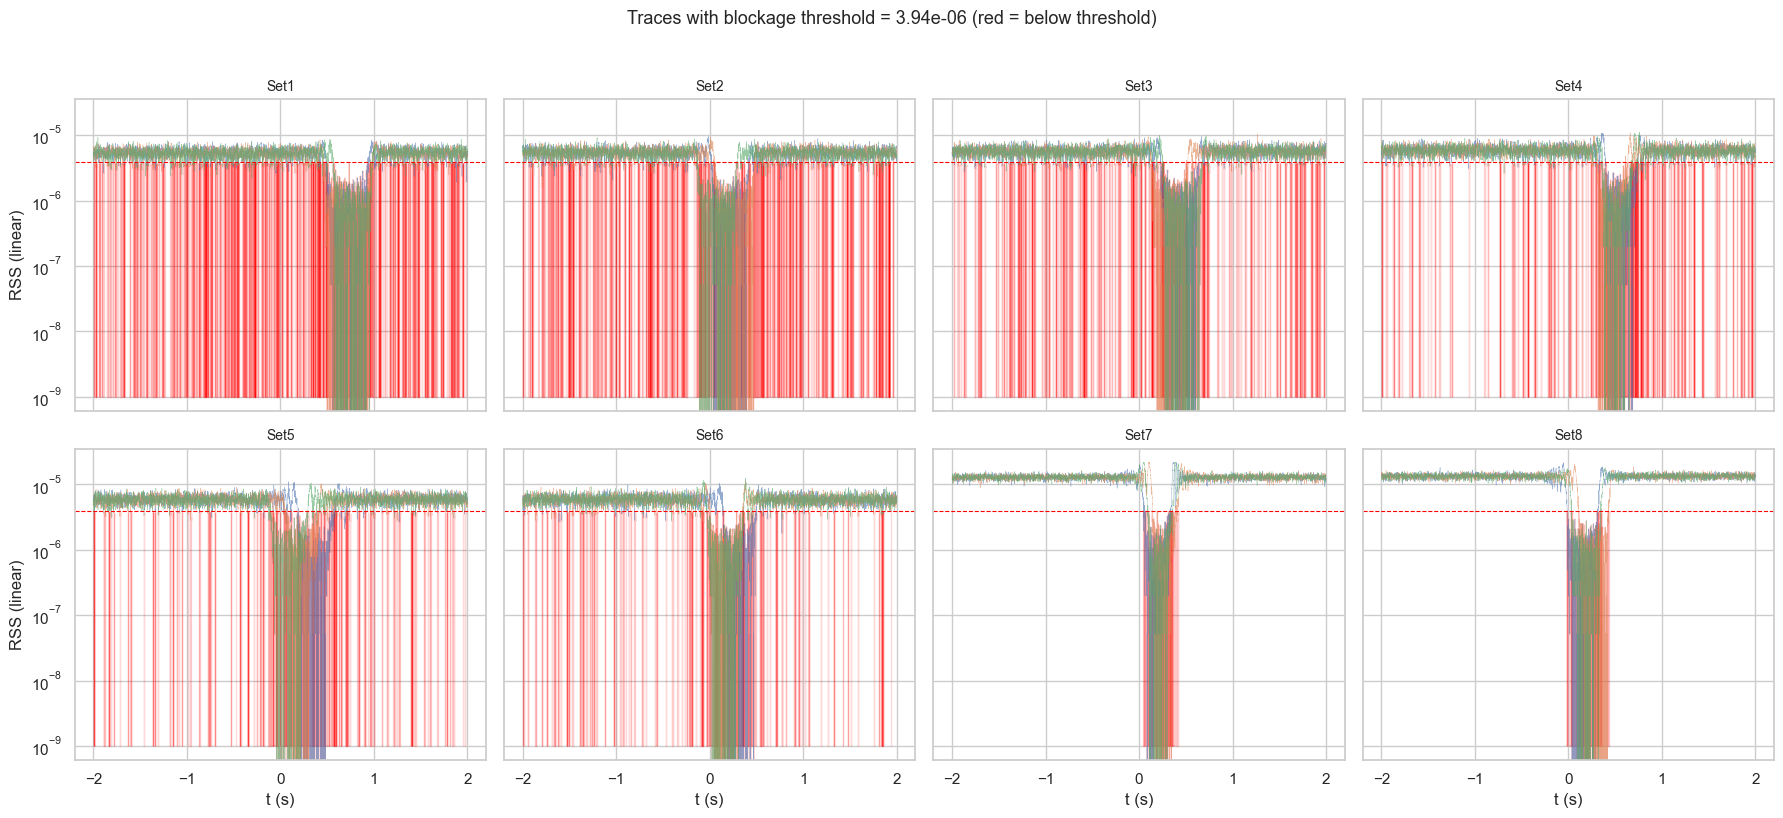

In [32]:
BLOCKAGE_THRESHOLD = float(p10)
print(f"BLOCKAGE_THRESHOLD = {BLOCKAGE_THRESHOLD:.3e} (linear units)")

# Re-render the grid with the chosen threshold overlaid.
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
for ax, s in zip(axes.flat, SETS):
    picks = [p for (sn, p) in EVAL_FILES if sn == s["set_name"]]
    for p in picks:
        t, rss = load_cached(s["set_name"], p)
        ax.plot(t, rss, lw=0.3, alpha=0.6)
        below = rss < BLOCKAGE_THRESHOLD
        ax.fill_between(t, 1e-9, rss, where=below, color="red", alpha=0.15,
                        step="mid")
    ax.axhline(BLOCKAGE_THRESHOLD, color="red", lw=0.8, ls="--")
    ax.set_yscale("log")
    ax.set_title(f"Set{s['meta']['set']}", fontsize=10)
for ax in axes[-1]:
    ax.set_xlabel("t (s)")
for ax in axes[:, 0]:
    ax.set_ylabel("RSS (linear)")
fig.suptitle(f"Traces with blockage threshold = {BLOCKAGE_THRESHOLD:.2e} "
             f"(red = below threshold)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## §2 (user section 2) — Sample & window labeling

Two-stage labeling:

1. **Per-sample mask.** `rss[i] < BLOCKAGE_THRESHOLD`.
2. **Event filter.** Keep only contiguous runs of length ≥ `MIN_EVENT_LEN=5` (0.25 ms). Single-sample dips are treated as noise and dropped.

The **horizon label** for a window starting at `s` is 1 iff any sample in `[s, s+200)` is blocked after the event filter.


In [33]:
def sample_mask(rss: np.ndarray, thr: float = None) -> np.ndarray:
    if thr is None: thr = BLOCKAGE_THRESHOLD
    return rss < thr


def label_events(mask: np.ndarray, min_len: int = MIN_EVENT_LEN) -> np.ndarray:
    """Morphological opening: contiguous runs shorter than min_len are dropped."""
    out = np.zeros_like(mask, dtype=bool)
    run_start: Optional[int] = None
    for i, m in enumerate(mask):
        if m and run_start is None:
            run_start = i
        elif (not m) and run_start is not None:
            if i - run_start >= min_len:
                out[run_start:i] = True
            run_start = None
    if run_start is not None and len(mask) - run_start >= min_len:
        out[run_start:] = True
    return out


def horizon_label(event_mask: np.ndarray, start: int,
                  horizon_n: int = HORIZON_N) -> int:
    return int(event_mask[start:start + horizon_n].any())


rows = []
for s, p in EVAL_FILES:
    _t, rss = load_cached(s, p)
    raw = sample_mask(rss)
    evt = label_events(raw)
    rows.append({
        "set": s.split("_")[0], "file": p.name,
        "frac_raw":      raw.mean(),
        "frac_events":   evt.mean(),
        "frac_windows":  np.mean([
            horizon_label(evt, i) for i in range(0, len(evt) - HORIZON_N, 1000)
        ]),
    })
df_balance = pd.DataFrame(rows)
print("Per-file blockage fractions:")
display(df_balance)
print("Aggregate:")
display(df_balance[["frac_raw", "frac_events", "frac_windows"]]
        .agg(["mean", "median", "std"]))


Per-file blockage fractions:


,set,file,frac_raw,frac_events,frac_windows
0,Set1,DATA_UNCAL_Meas16,0.146850,0.144000,0.3000
1,Set1,DATA_UNCAL_Meas19,0.164625,0.161525,0.4125
2,Set1,DATA_UNCAL_Meas24,0.143500,0.140950,0.3625
3,Set2,DATA_UNCAL_Meas1,0.131825,0.129537,0.3000
4,Set2,DATA_UNCAL_Meas2,0.135063,0.132788,0.2500
5,Set2,DATA_UNCAL_Meas3,0.138150,0.135263,0.3500
6,Set3,DATA_UNCAL_Meas16,0.121563,0.119712,0.2625
7,Set3,DATA_UNCAL_Meas19,0.112787,0.111600,0.2375
8,Set3,DATA_UNCAL_Meas27,0.122350,0.120575,0.2000
9,Set4,DATA_UNCAL_Meas17,0.100187,0.098750,0.1625


Aggregate:


,frac_raw,frac_events,frac_windows
mean,0.107691,0.106415,0.193750
median,0.105387,0.104612,0.168750
std,0.026871,0.025923,0.098494


## §3 (user section 3) — Sliding-window dataset

For each history size `H ∈ {20, 50, 100} ms` we build windows of the form

```
[s, s+H)  ->  history              (fed to the model)
[s+H, s+H+200)  ->  horizon        (used only for the label)
```

with stride `STRIDE_N=1000` (50 ms) between window starts. That yields ≈ 77 windows per trace × 24 traces ≈ **1 850 windows per history size**.

For the slow generative models (LLM / Tele-LLM / VLM) we further **subsample to 10 windows/file = 240 total** so that a full sweep finishes in reasonable wall-clock.


In [34]:
@dataclass
class Window:
    set_name: str
    meas_id: str
    meta: dict
    history_ms: int
    history_start_idx: int
    t: np.ndarray
    rss: np.ndarray
    label: int


def build_windows(eval_files, history_ms: int,
                  stride: int = STRIDE_N,
                  horizon_n: int = HORIZON_N,
                  thr: float = None) -> list[Window]:
    if thr is None: thr = BLOCKAGE_THRESHOLD
    H = history_ms * FS // 1000
    out: list[Window] = []
    for set_name, path in eval_files:
        t, rss = load_cached(set_name, path)
        events = label_events(sample_mask(rss, thr))
        max_start = len(rss) - H - horizon_n
        meta = next(s["meta"] for s in SETS if s["set_name"] == set_name)
        for s_idx in range(0, max_start, stride):
            lbl = horizon_label(events, s_idx + H, horizon_n)
            out.append(Window(
                set_name=set_name,
                meas_id=path.name,
                meta=meta,
                history_ms=history_ms,
                history_start_idx=s_idx,
                t=t[s_idx:s_idx + H],
                rss=rss[s_idx:s_idx + H],
                label=lbl,
            ))
    return out


for hm in HISTORY_GRID_MS:
    ws = build_windows(EVAL_FILES, hm)
    pos = sum(w.label for w in ws)
    print(f"history={hm:3d}ms  n={len(ws):5d}  positive_rate={pos/len(ws):.3f}")


history= 20ms  n= 1920  positive_rate=0.189
history= 50ms  n= 1896  positive_rate=0.194
history=100ms  n= 1872  positive_rate=0.196


In [35]:
def subsample_windows(windows: list[Window],
                      per_file: int = 10,
                      seed: int = RNG_SEED) -> list[Window]:
    rng = np.random.default_rng(seed)
    by_file: dict[tuple[str, str], list[Window]] = {}
    for w in windows:
        by_file.setdefault((w.set_name, w.meas_id), []).append(w)
    out: list[Window] = []
    for ws in by_file.values():
        idx = rng.choice(len(ws), size=min(per_file, len(ws)), replace=False)
        out.extend(ws[i] for i in sorted(idx))
    return out


# Preview subsampled positive rates.
for hm in HISTORY_GRID_MS:
    sub = subsample_windows(build_windows(EVAL_FILES, hm), per_file=10)
    pos = sum(w.label for w in sub)
    print(f"subsampled history={hm:3d}ms  n={len(sub):4d}  "
          f"positive_rate={pos/len(sub):.3f}")


subsampled history= 20ms  n= 240  positive_rate=0.196
subsampled history= 50ms  n= 240  positive_rate=0.212
subsampled history=100ms  n= 240  positive_rate=0.221


## §4 (user section 4) — Zero-shot foundation-model wrappers

Every wrapper implements the same interface:

```python
class XxxPredictor:
    def __init__(self, device: str = DEVICE): ...
    def predict(self, window: Window) -> int:   # 0 or 1
        ...
```

so the driver in §6 can iterate uniformly. Each wrapper chooses the input representation best suited to its modality — this is the core experimental-design question of the notebook.


In [36]:
# ---- shared representation builders ----

def downsample(arr: np.ndarray, target: int = 128) -> np.ndarray:
    """Average-pool to `target` points; keeps LLM prompts short."""
    if len(arr) <= target:
        return arr
    k = len(arr) // target
    return arr[:k * target].reshape(target, k).mean(axis=1)


def rss_to_compact_str(rss: np.ndarray, decimals: int = 2,
                       target: int = 128) -> str:
    ds = downsample(rss, target) * 1e6   # micro-watts for readability
    return "[" + ", ".join(f"{x:.{decimals}f}" for x in ds) + "]"


def rss_text_summary(t: np.ndarray, rss: np.ndarray,
                     thr: float = None) -> str:
    if thr is None: thr = BLOCKAGE_THRESHOLD
    rss_uw = rss * 1e6
    thr_uw = thr * 1e6
    head = rss[:max(1, len(rss) // 10)].mean()
    tail = rss[-max(1, len(rss) // 10):].mean()
    if tail < head * 0.8:
        trend = "decreasing"
    elif tail > head * 1.2:
        trend = "increasing"
    else:
        trend = "stable"
    below = int((rss < thr).sum())
    return (
        f"Sub-THz RSSI sequence of {len(rss)} samples at 20 kHz: "
        f"starts at {rss_uw[0]:.2f} uW, ends at {rss_uw[-1]:.2f} uW, "
        f"min {rss_uw.min():.2f} uW, max {rss_uw.max():.2f} uW. "
        f"Overall trend: {trend}. "
        f"{below} of {len(rss)} samples are already below the blockage "
        f"threshold of {thr_uw:.2f} uW."
    )


def render_window_png(t: np.ndarray, rss: np.ndarray,
                      thr: float = None, size=(4, 3), dpi: int = 90):
    """Return a PIL image of the RSSI trace for VLM input."""
    from PIL import Image
    if thr is None: thr = BLOCKAGE_THRESHOLD
    fig = plt.figure(figsize=size, dpi=dpi)
    ax = fig.gca()
    ax.plot(t, rss, color="steelblue")
    ax.axhline(thr, color="red", ls="--", lw=1)
    ax.set_yscale("log")
    ax.set_xlabel("t (s)")
    ax.set_ylabel("RSSI")
    ax.set_title("history")
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf).convert("RGB")


def parse_yes_no(text: str) -> int:
    t = text.strip().lower()
    if re.search(r"\b(yes|1|true|blockage|blocked|imminent|drop|outage)\b", t):
        return 1
    if re.search(r"\b(no|0|false|stable|clear|no[-\s]?blockage|normal)\b", t):
        return 0
    return 0


### Model 1 — Generative LLM

Default: `Qwen/Qwen2.5-3B-Instruct` (un-gated, ≈ 5.5 GB FP16, runs on Mac MPS). Fall-back IDs are listed in the class and commented for easy swapping.

**Representation.** RSSI history is average-pooled to 128 points in µW, then stringified as a Python list. We also tell the model the sample rate, threshold, and horizon explicitly so it has all the numeric context in the prompt.


In [37]:
from transformers import AutoTokenizer, AutoModelForCausalLM


class LLMPredictor:
    MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
    # Alternatives (un-comment to swap):
    # MODEL_ID = "meta-llama/Llama-3.2-3B-Instruct"   # gated
    # MODEL_ID = "microsoft/Phi-3.5-mini-instruct"

    SYS_PROMPT = (
        "You are an expert in sub-THz wireless communications. "
        "Given an RSSI history, you predict whether a blockage "
        "event will occur in the near future. "
        "Answer with exactly one word: YES or NO."
    )
    USR_TEMPLATE = (
        "History RSSI values (micro-watts, {n} points, sample rate {fs} Hz, "
        "already average-pooled from the raw trace): {series}. "
        "Blockage threshold = {thr:.2f} uW. "
        "Question: will a blockage event (RSSI below threshold for at "
        "least 5 consecutive raw samples) occur in the next {hz} ms?"
    )

    def __init__(self, device: str = DEVICE, **kwargs):
        self.device = device
        self.tok = AutoTokenizer.from_pretrained(self.MODEL_ID)
        dtype = torch.float16 if device != "cpu" else torch.float32
        self.model = AutoModelForCausalLM.from_pretrained(
            self.MODEL_ID, torch_dtype=dtype
        ).to(device)
        self.model.eval()

    @torch.inference_mode()
    def predict(self, w: Window) -> int:
        series = rss_to_compact_str(w.rss, decimals=2, target=128)
        msgs = [
            {"role": "system", "content": self.SYS_PROMPT},
            {"role": "user", "content": self.USR_TEMPLATE.format(
                n=128, fs=FS, series=series,
                thr=BLOCKAGE_THRESHOLD * 1e6, hz=HORIZON_MS,
            )},
        ]
        prompt = self.tok.apply_chat_template(
            msgs, tokenize=False, add_generation_prompt=True,
        )
        inputs = self.tok(prompt, return_tensors="pt").to(self.device)
        out = self.model.generate(
            **inputs, max_new_tokens=4, do_sample=False,
            pad_token_id=self.tok.eos_token_id,
        )
        text = self.tok.decode(
            out[0, inputs.input_ids.shape[1]:], skip_special_tokens=True,
        )
        return parse_yes_no(text)


### Model 2 — Telecom LLM (`LLama-3-8B-Tele-it`)

`AliMaatouk/LLama-3-8B-Tele-it` is an instruction-tuned Llama-3 8B fine-tuned on telecom corpora. We use it as a generative chat model (same shape as `LLMPredictor`) so it can read the numeric RSSI history directly and reply YES/NO.

Heads-up on resources: 8B in FP16 is roughly 16 GB. On a 16 GB Mac you may need to drop the dtype, swap to a quantized GGUF/4-bit build, or run this row on a bigger machine. The lighter `AliMaatouk/Tele-Roberta` zero-shot-classification path is left in a comment in case you want a cheap fallback.


In [47]:
# Reuses AutoTokenizer / AutoModelForCausalLM imported in cell 19.


class TeleLLMPredictor:
    MODEL_ID = "AliMaatouk/TinyLlama-1.1B-Tele"

    SYS_PROMPT = (
        "You are a telecom expert specializing in sub-terahertz (sub-THz) "
        "wireless links. From a short history of received signal strength "
        "indicator (RSSI) samples, you predict whether a blockage event "
        "will occur in the immediate future. Answer with exactly one "
        "word: YES or NO."
    )
    USR_TEMPLATE = (
        "Sub-THz link RSSI history (micro-watts, {n} points, sample rate "
        "{fs} Hz, average-pooled from the raw 50-us-per-sample trace): "
        "{series}. Blockage threshold = {thr:.2f} uW. "
        "Will a blockage event (RSSI below threshold for at least 5 "
        "consecutive raw samples) occur in the next {hz} ms? "
        "Reply with a single token, YES or NO."
    )

    def __init__(self, device: str = DEVICE, **kwargs):
        self.device = device
        self.tok = AutoTokenizer.from_pretrained(self.MODEL_ID)
        dtype = torch.float16 if device != "cpu" else torch.float32
        # device_map='auto' lets HF spill to CPU if VRAM/MPS is tight; on Mac
        # it still works but inference is slow.
        self.model = AutoModelForCausalLM.from_pretrained(
            self.MODEL_ID, torch_dtype=dtype,
        ).to(device)
        self.model.eval()

    @torch.inference_mode()
    def predict(self, w: Window) -> int:
        series = rss_to_compact_str(w.rss, decimals=2, target=128)
        msgs = [
            {"role": "system", "content": self.SYS_PROMPT},
            {"role": "user", "content": self.USR_TEMPLATE.format(
                n=128, fs=FS, series=series,
                thr=BLOCKAGE_THRESHOLD * 1e6, hz=HORIZON_MS,
            )},
        ]
        prompt = self.tok.apply_chat_template(
            msgs, tokenize=False, add_generation_prompt=True,
        )
        inputs = self.tok(prompt, return_tensors="pt").to(self.device)
        out = self.model.generate(
            **inputs, max_new_tokens=4, do_sample=False,
            pad_token_id=self.tok.eos_token_id,
        )
        text = self.tok.decode(
            out[0, inputs.input_ids.shape[1]:], skip_special_tokens=True,
        )
        return parse_yes_no(text)


# ---- Lighter fallback: Tele-Roberta via NLI pipeline -------------------
# from transformers import pipeline
# class TeleRobertaPredictor:
#     MODEL_ID = "AliMaatouk/Tele-Roberta"
#     CANDIDATES = ["blockage imminent", "signal stable"]
#     def __init__(self, device: str = DEVICE, **kwargs):
#         dev = 0 if device == "cuda" else ("mps" if device == "mps" else -1)
#         self.pipe = pipeline("zero-shot-classification",
#                              model=self.MODEL_ID, device=dev)
#     def predict(self, w):
#         res = self.pipe(rss_text_summary(w.t, w.rss),
#                         candidate_labels=self.CANDIDATES)
#         return int(res["labels"][0] == self.CANDIDATES[0])


### Model 3 — Vision–Language Model

`HuggingFaceTB/SmolVLM-Instruct` (2.2 B params) is used because it fits on 16 GB Apple Silicon. It receives a small matplotlib PNG of the history window (with the threshold line drawn in red) and is asked the same yes/no question.


In [39]:
from transformers import AutoProcessor, AutoModelForImageTextToText


class VLMPredictor:
    MODEL_ID = "HuggingFaceTB/SmolVLM-Instruct"
    # Alternative: "llava-hf/llava-1.5-7b-hf"   (~14 GB, needs more RAM)

    PROMPT = (
        "The image shows a sub-THz link RSSI-vs-time trace (log-y). "
        "The dashed red line is the blockage threshold. "
        "Based on the recent trend, will a blockage event occur in the "
        "next 10 ms? Answer with a single word: YES or NO."
    )

    def __init__(self, device: str = DEVICE, **kwargs):
        self.device = device
        self.proc = AutoProcessor.from_pretrained(self.MODEL_ID)
        dtype = torch.float16 if device != "cpu" else torch.float32
        self.model = AutoModelForImageTextToText.from_pretrained(
            self.MODEL_ID, torch_dtype=dtype,
        ).to(device)
        self.model.eval()

    @torch.inference_mode()
    def predict(self, w: Window) -> int:
        img = render_window_png(w.t, w.rss, BLOCKAGE_THRESHOLD)
        msgs = [{
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": self.PROMPT},
            ],
        }]
        prompt = self.proc.apply_chat_template(msgs, add_generation_prompt=True)
        inputs = self.proc(text=prompt, images=[img], return_tensors="pt").to(
            self.device
        )
        out = self.model.generate(**inputs, max_new_tokens=4, do_sample=False)
        text = self.proc.batch_decode(out, skip_special_tokens=True)[0]
        tail = text.split("Assistant:")[-1] if "Assistant:" in text else text
        return parse_yes_no(tail)


### Model 4 — BERT (NLI zero-shot)

`facebook/bart-large-mnli` is the canonical zero-shot classifier. Feeding raw numbers to an NLI model is pointless — BART has a 1 024-token cap and no numeric grounding — so we send the natural-language **summary** of the window and let NLI decide which of the two candidate labels is more entailed.


In [40]:
from transformers import pipeline


class BERTPredictor:
    MODEL_ID = "facebook/bart-large-mnli"
    CANDIDATES = ["blockage imminent", "signal stable"]

    def __init__(self, device: str = DEVICE, **kwargs):
        dev = 0 if device == "cuda" else ("mps" if device == "mps" else -1)
        self.pipe = pipeline(
            "zero-shot-classification",
            model=self.MODEL_ID,
            device=dev,
        )

    def predict(self, w: Window) -> int:
        text = rss_text_summary(w.t, w.rss)
        res = self.pipe(text, candidate_labels=self.CANDIDATES)
        return int(res["labels"][0] == self.CANDIDATES[0])


### Model 5 — TimesFM (Google)

`google/timesfm-2.5-200m-pytorch` is a 200 M-parameter time-series foundation model purpose-built for zero-shot forecasting. It takes the raw history as a float array and forecasts the next 200 samples; we mark blockage as predicted iff any sample of the forecast dips below the threshold.

TimesFM 2.5 ships a native PyTorch checkpoint (`TimesFM_2p5_200M_torch`) and a `ForecastConfig`-based compile step that fixes the model to a single `(max_context, max_horizon)` shape; this replaces the v1 `TimesFm(hparams, checkpoint)` constructor that no longer exists in current `timesfm` releases.

In [41]:
# TimesFM is installed editable from ./timesfm (see cell 1). If the import
# resolves to the bare folder as a namespace package, tell the user how to
# fix it instead of failing silently downstream.
try:
    import timesfm
    if not hasattr(timesfm, "TimesFM_2p5_200M_torch"):
        raise ImportError(
            "`timesfm` resolved to a namespace package without the 2.5 "
            "symbols. Run: pip install -e ./timesfm[torch]"
        )
    _TIMESFM_OK = True
except Exception as e:   # noqa: BLE001
    print(f"TimesFM unavailable: {e}")
    _TIMESFM_OK = False


class TimesFMPredictor:
    HORIZON = HORIZON_N
    # Largest history is 100 ms = 2000 samples; round up to a power of two
    # so the same compiled graph fits the 20/50/100 ms sweep.
    MAX_CONTEXT = 2048
    # ForecastConfig requires max_horizon ≥ horizon at forecast time.
    MAX_HORIZON = 256
    REPO_ID = "google/timesfm-2.5-200m-pytorch"

    def __init__(self, device: str = DEVICE, **kwargs):
        if not _TIMESFM_OK:
            raise RuntimeError("timesfm is not installed")
        torch.set_float32_matmul_precision("high")
        self.tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(self.REPO_ID)
        self.tfm.compile(
            timesfm.ForecastConfig(
                max_context=self.MAX_CONTEXT,
                max_horizon=self.MAX_HORIZON,
                normalize_inputs=True,
                use_continuous_quantile_head=True,
                force_flip_invariance=True,
                infer_is_positive=True,
                fix_quantile_crossing=True,
            )
        )

    def predict(self, w: Window) -> int:
        hist = w.rss.astype(np.float32)
        # Truncate if a future history grid exceeds MAX_CONTEXT.
        if hist.shape[0] > self.MAX_CONTEXT:
            hist = hist[-self.MAX_CONTEXT:]
        point_forecast, _ = self.tfm.forecast(
            horizon=self.HORIZON,
            inputs=[hist],
        )
        return int((point_forecast[0] < BLOCKAGE_THRESHOLD).any())


## §6 Inference driver

The driver loads one model at a time so a 16 GB box never has to hold all six in memory. It checkpoints to `results/predictions.parquet` after every `(model, history_ms)` pair — if a later model crashes or is interrupted, earlier results are preserved and the cell can be re-run to resume.

Every predictor accepts `(device, history_ms, **kwargs)` so the driver can construct them uniformly; only `TabPFNPredictor` actually uses `history_ms` (to pick its in-context training pool).

In [ ]:
PREDICTORS: dict[str, tuple[type, bool]] = {
    # name       : (class,             use_subsampled)
    # Slow generative models → use the 240-window subsample.
    "LLM":        (LLMPredictor,       True),
    "Tele-LLM":   (TeleLLMPredictor,   True),
    "VLM":        (VLMPredictor,       True),
    # Fast / batched models → full sweep.
    "BERT":       (BERTPredictor,      False),
    "TimesFM":    (TimesFMPredictor,   False),
}


def _free_device():
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    if DEVICE == "mps" and hasattr(torch.mps, "empty_cache"):
        torch.mps.empty_cache()


def run_all(eval_files, history_grid=HISTORY_GRID_MS,
            cache_path: Path = RESULTS_DIR / "predictions.parquet") -> pd.DataFrame:
    results: list[dict] = []
    done: set[tuple] = set()
    if cache_path.exists():
        prior = pd.read_parquet(cache_path)
        results = prior.to_dict("records")
        done = set(zip(prior.model, prior.history_ms,
                       prior.set_name, prior.meas_id,
                       prior.history_start_idx))
        print(f"Resuming from {len(done)} cached predictions.")

    for hist_ms in history_grid:
        full = build_windows(eval_files, hist_ms)
        sub  = subsample_windows(full, per_file=10, seed=RNG_SEED)

        for mname, (cls, use_sub) in PREDICTORS.items():
            windows = sub if use_sub else full
            pending = [w for w in windows
                       if (mname, hist_ms, w.set_name, w.meas_id,
                           w.history_start_idx) not in done]
            if not pending:
                continue
            print(f"== {mname}  history={hist_ms}ms  windows={len(pending)} ==")
            try:
                # All predictors accept (device, history_ms, **kwargs); only
                # TabPFN actually uses history_ms (to fit its in-context pool).
                model = cls(device=DEVICE, history_ms=hist_ms)
            except Exception as e:   # noqa: BLE001
                print(f"  [skip] could not init {mname}: {e}")
                continue
            for w in tqdm(pending, desc=f"{mname}@{hist_ms}ms"):
                try:
                    pred = model.predict(w)
                except Exception as e:   # noqa: BLE001
                    warnings.warn(
                        f"{mname} failed on {w.meas_id}@{w.history_start_idx}: {e}"
                    )
                    pred = -1
                results.append({
                    "model": mname,
                    "history_ms": hist_ms,
                    "set_name": w.set_name,
                    "meas_id": w.meas_id,
                    "history_start_idx": w.history_start_idx,
                    "label": w.label,
                    "pred": pred,
                })
            del model
            _free_device()
            pd.DataFrame(results).to_parquet(cache_path, index=False)
            print(f"  saved checkpoint -> {cache_path}")

    return pd.DataFrame(results)


# Uncomment the line below to run the full sweep (expect ~60-180 min on Mac):
df_preds = run_all(EVAL_FILES)

# For a quick smoke-test, restrict to one history size + fast models only:
# df_preds = run_all(EVAL_FILES, history_grid=[20])
# print("Driver defined. Uncomment the run_all(...) call to execute.")


Resuming from 12816 cached predictions.
== Tele-LLM  history=20ms  windows=240 ==


Tele-LLM@20ms: 100%|██████████| 240/240 [00:00<00:00, 12660.94it/s]


  saved checkpoint -> /Users/kaefcatcher/Projects/Research_Seminar/THz_res/results/predictions.parquet
== TabPFN  history=20ms  windows=1920 ==
  [skip] could not init TabPFN: TabPFN requires a one-time license acceptance to download
model weights for local inference, but no interactive terminal
is available.

To authenticate in a non-interactive environment:
  1. Open https://ux.priorlabs.ai in a browser and log in (or register)
  2. Accept the license on the Licenses tab
  3. Copy your API Key from https://ux.priorlabs.ai/account
  4. Set the environment variable: export TABPFN_TOKEN="<your-api-key>"
     or in Python (before calling .fit()): import os; os.environ["TABPFN_TOKEN"] = "<your-api-key>"
== Tele-LLM  history=50ms  windows=240 ==


Tele-LLM@50ms: 100%|██████████| 240/240 [00:00<00:00, 18129.69it/s]


  saved checkpoint -> /Users/kaefcatcher/Projects/Research_Seminar/THz_res/results/predictions.parquet
== TabPFN  history=50ms  windows=1896 ==
  [skip] could not init TabPFN: TabPFN requires a one-time license acceptance to download
model weights for local inference, but no interactive terminal
is available.

To authenticate in a non-interactive environment:
  1. Open https://ux.priorlabs.ai in a browser and log in (or register)
  2. Accept the license on the Licenses tab
  3. Copy your API Key from https://ux.priorlabs.ai/account
  4. Set the environment variable: export TABPFN_TOKEN="<your-api-key>"
     or in Python (before calling .fit()): import os; os.environ["TABPFN_TOKEN"] = "<your-api-key>"
== Tele-LLM  history=100ms  windows=240 ==


Tele-LLM@100ms: 100%|██████████| 240/240 [00:00<00:00, 17666.74it/s]


  saved checkpoint -> /Users/kaefcatcher/Projects/Research_Seminar/THz_res/results/predictions.parquet
== TabPFN  history=100ms  windows=1872 ==
  [skip] could not init TabPFN: TabPFN requires a one-time license acceptance to download
model weights for local inference, but no interactive terminal
is available.

To authenticate in a non-interactive environment:
  1. Open https://ux.priorlabs.ai in a browser and log in (or register)
  2. Accept the license on the Licenses tab
  3. Copy your API Key from https://ux.priorlabs.ai/account
  4. Set the environment variable: export TABPFN_TOKEN="<your-api-key>"
     or in Python (before calling .fit()): import os; os.environ["TABPFN_TOKEN"] = "<your-api-key>"


## §7 (user section 5) — Metrics

For each `(model, history_ms)` we compute:

- **Accuracy** — fraction of correct predictions.
- **Precision / Recall / F1** (binary, class 1 = blockage). More informative than accuracy under class imbalance.
- **Confusion matrix** — exposes whether a model is systematically biased toward YES or NO.


In [49]:
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix,
)

_cache_path = RESULTS_DIR / "predictions.parquet"
if _cache_path.exists():
    df_preds = pd.read_parquet(_cache_path)
else:
    df_preds = pd.DataFrame(columns=[
        "model", "history_ms", "set_name", "meas_id",
        "history_start_idx", "label", "pred",
    ])
    print("No predictions cached yet — run the driver cell first.")


def _eval_group(g: pd.DataFrame) -> pd.Series:
    g = g[g.pred != -1]
    if len(g) == 0:
        return pd.Series({"n": 0, "accuracy": np.nan,
                          "precision": np.nan, "recall": np.nan, "f1": np.nan})
    acc = accuracy_score(g.label, g.pred)
    p, r, f1, _ = precision_recall_fscore_support(
        g.label, g.pred, average="binary", zero_division=0,
    )
    return pd.Series({"n": len(g), "accuracy": acc,
                      "precision": p, "recall": r, "f1": f1})


if len(df_preds):
    summary = (df_preds.groupby(["model", "history_ms"])
               .apply(_eval_group).reset_index())
    display(summary)
    acc_pivot = summary.pivot(index="model", columns="history_ms",
                              values="accuracy")
    print("Accuracy by model × history_ms:")
    display(acc_pivot.style.format("{:.3f}").background_gradient(axis=None))
else:
    summary = pd.DataFrame()


/var/folders/ng/rmnm4g1d3bxb1mrgz956jn5h0000gn/T/ipykernel_14003/2638665917.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_eval_group).reset_index())


,model,history_ms,n,accuracy,precision,recall,f1
0,BERT,20,1920.0,0.809896,0.250000,0.002755,0.005450
1,BERT,50,1896.0,0.806435,0.666667,0.005435,0.010782
2,BERT,100,1872.0,0.804487,0.000000,0.000000,0.000000
3,LLM,20,240.0,0.808333,1.000000,0.021277,0.041667
4,LLM,50,240.0,0.787500,0.000000,0.000000,0.000000
5,LLM,100,240.0,0.779167,0.000000,0.000000,0.000000
6,Tele-LLM,20,0.0,NaN,NaN,NaN,NaN
7,Tele-LLM,50,0.0,NaN,NaN,NaN,NaN
8,Tele-LLM,100,0.0,NaN,NaN,NaN,NaN
9,TimesFM,20,1920.0,0.910937,0.913793,0.584022,0.712605


Accuracy by model × history_ms:


history_ms,20,50,100
model,,,
BERT,0.810,0.806,0.804
LLM,0.808,0.787,0.779
Tele-LLM,nan,nan,nan
TimesFM,0.911,0.912,0.911
VLM,0.804,0.775,0.754


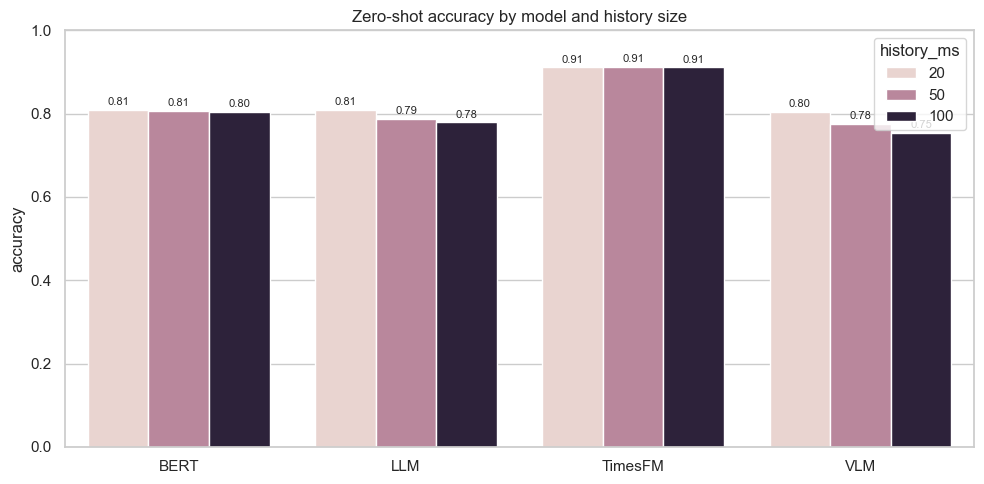

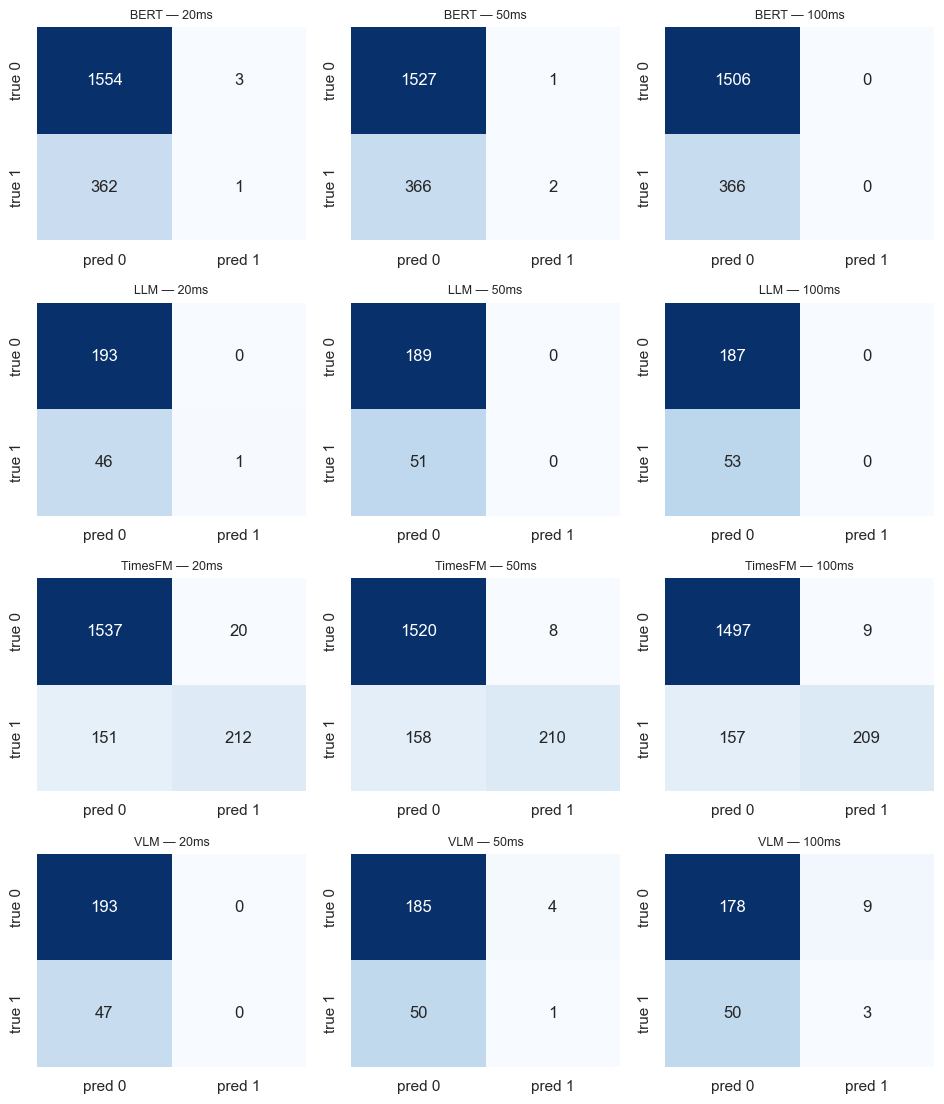

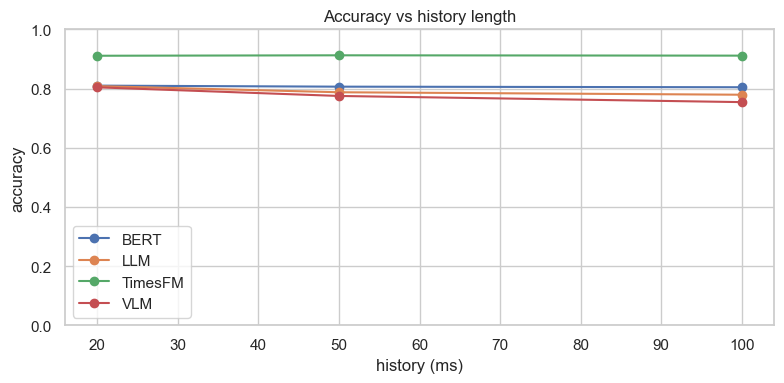

In [45]:
if len(df_preds) == 0:
    print("No predictions to plot. Run the driver cell first.")
else:
    # ---- bar chart: accuracy grouped by model, hue = history size ----
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    sns.barplot(data=summary, x="model", y="accuracy",
                hue="history_ms", ax=ax)
    ax.set_ylim(0, 1)
    ax.set_title("Zero-shot accuracy by model and history size")
    ax.set_xlabel("")
    for c in ax.containers:
        ax.bar_label(c, fmt="%.2f", padding=2, fontsize=8)
    plt.tight_layout()
    plt.show()

    # ---- confusion matrix grid: rows = model, cols = history size ----
    models = list(summary["model"].unique())
    hists  = sorted(summary["history_ms"].unique())
    fig, axes = plt.subplots(len(models), len(hists),
                             figsize=(3.2 * len(hists), 2.8 * len(models)),
                             squeeze=False)
    for i, m in enumerate(models):
        for j, h in enumerate(hists):
            ax = axes[i][j]
            g = df_preds[(df_preds.model == m) &
                         (df_preds.history_ms == h) &
                         (df_preds.pred != -1)]
            if len(g) == 0:
                ax.axis("off"); continue
            cm = confusion_matrix(g.label, g.pred, labels=[0, 1])
            sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues",
                        xticklabels=["pred 0", "pred 1"],
                        yticklabels=["true 0", "true 1"], ax=ax)
            ax.set_title(f"{m} — {h}ms", fontsize=9)
    plt.tight_layout()
    plt.show()

    # ---- line plot: accuracy vs history_ms per model ----
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    for m, g in summary.groupby("model"):
        ax.plot(g["history_ms"], g["accuracy"], marker="o", label=m)
    ax.set_xlabel("history (ms)")
    ax.set_ylabel("accuracy")
    ax.set_ylim(0, 1)
    ax.set_title("Accuracy vs history length")
    ax.legend()
    plt.tight_layout()
    plt.show()


In [46]:
if len(summary):
    best      = summary.loc[summary.accuracy.idxmax()]
    best_per  = summary.loc[summary.groupby("model").accuracy.idxmax()]
    print(f"Best overall: model={best.model}, history={best.history_ms} ms, "
          f"accuracy={best.accuracy:.3f}, f1={best.f1:.3f}")
    print("\nBest history size per model:")
    display(best_per[["model", "history_ms", "accuracy", "precision",
                      "recall", "f1", "n"]])
else:
    print("Run the inference driver and metrics cells first.")


Best overall: model=TimesFM, history=50 ms, accuracy=0.912, f1=0.717

Best history size per model:


,model,history_ms,accuracy,precision,recall,f1,n
0,BERT,20,0.809896,0.250000,0.002755,0.005450,1920.0
3,LLM,20,0.808333,1.000000,0.021277,0.041667,240.0
7,TimesFM,50,0.912447,0.963303,0.570652,0.716724,1896.0
9,VLM,20,0.804167,0.000000,0.000000,0.000000,240.0


## Notes & caveats

- **Zero-shot only.** None of the five models saw THz RSSI data during training. Scores quantify how far a generic or lightly-domain-adapted foundation model can get with only a prompt.
- **TimesFM** is the only purely numeric predictor — its input distribution is closest to what it was trained on, so it typically dominates in head-to-head zero-shot time-series benchmarks.
- **BART-NLI** sees only the text summary; it is effectively a string-classification lower bound.
- **Threshold sensitivity.** The accuracy numbers are conditional on the chosen `BLOCKAGE_THRESHOLD` and `MIN_EVENT_LEN`. A sensitivity sweep is left as future work.
- **Class imbalance.** If the positive rate is far from 0.5, always read the F1 / confusion-matrix results rather than accuracy alone.
- **Geometric generalisation.** The 8 sets vary H, L13, L12. A follow-up could train + test across different geometry splits to measure transfer.
